## Pina tutorial

In this tutorial, we will see hows to use the python module pina-mathlab to more easily construct and train PINNs.

This tutorial is adapted from pina's own tutorials, which are available [here](https://mathlab.github.io/PINA/_tutorial.html). If you want to learn more about using pina, these tutorials are a good place to start.

In [1]:
!pip install "pina-mathlab"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 761.0 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.4/234.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 25.3 MB/s eta 0:00:00


# Pina workflow

The typical worklflow of solving a problem using a PINN with pina is shown in the picture below.

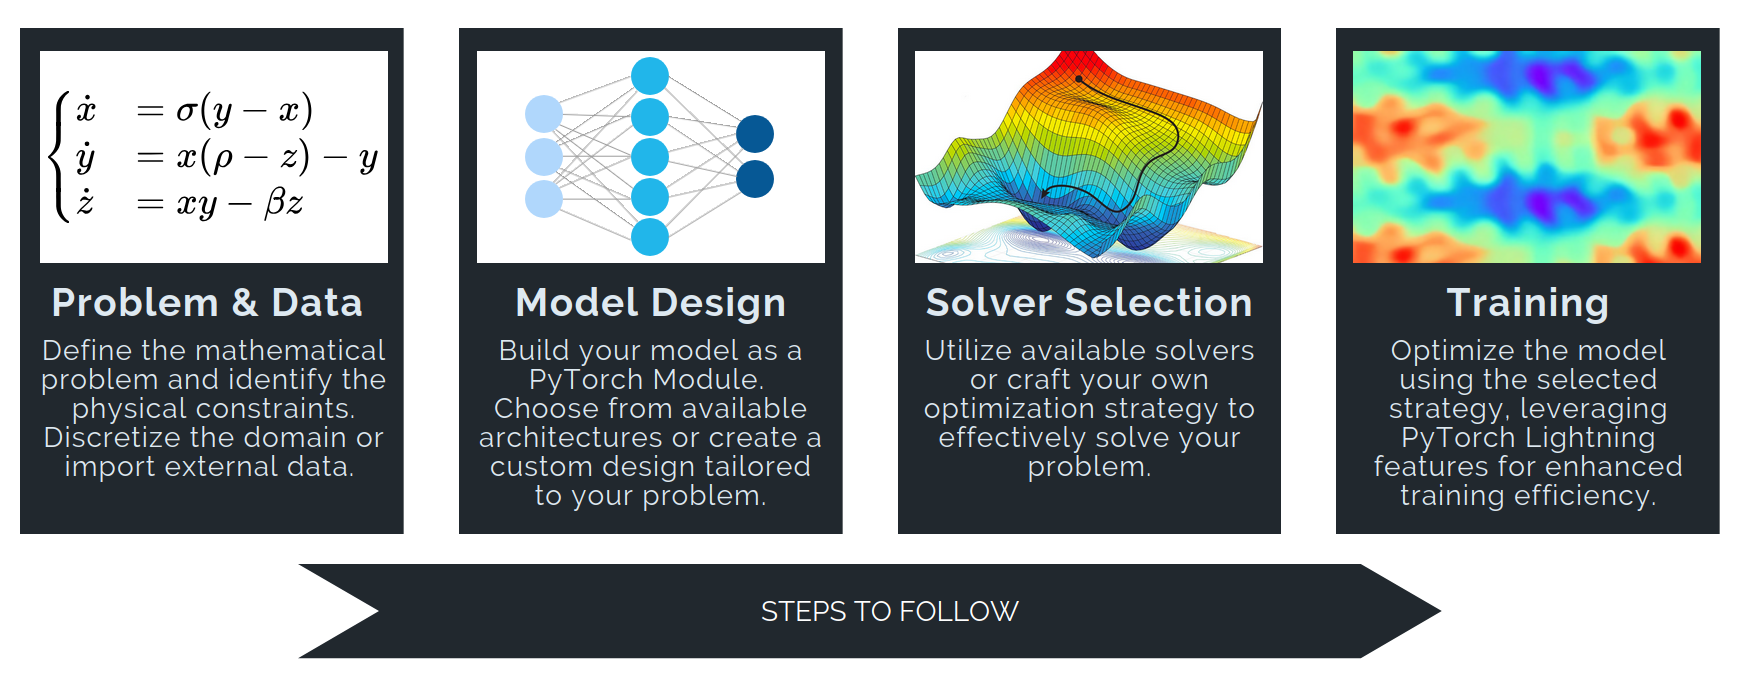



# Step 1: Building the problem

Pina is an object-oriented physics informed module for physics-informed machine learning.

To solve a problem with pina, we must first define our problem object.

To do so, we create a class that inherits from the pina problem base classes, which are:
   - `TimeDependentProblem`
   - `SpatialProblem`
   - `InverseProblem`  
   - `ParametricProblem`  
   - ...

Here, we will use pina to solve a 2-dimensional Poisson problem written as:
\begin{equation}
\begin{cases}
\Delta u = 2\pi^2\sin{(\pi x)} \sin{(\pi y)} \text{ in } D, \\
u = 0 \text{ on } B_1 \cup B_2 \cup B_3 \cup B_4,
\end{cases}
\end{equation}
where $D$ is the square domain $[0,1]^2$, and $B_i$, with $i=1,...,4$, are the boundaries of the square.

As this problem is purely spatial, we will create our problem class inheriting from pina.problem.SpatialProblem

Inside the problem class, we must defined the input variables, output variables, the problem domain, subdomains if needed (for example the boundaries, for the definition of boundary conditions), and all the conditions (i.e. loss function terms) that we need.

In [6]:

import torch
import matplotlib.pyplot as plt

from pina.problem import SpatialProblem
from pina.domain import CartesianDomain
from pina import Condition
from pina.equation import Equation, FixedValue

from pina.operator import laplacian



# Function that computes the residuals of the poisson equation

def poisson(input_, output_):

    # computing the laplacian
    delta_u = laplacian(output_, input_, components=["u"], d=["x","y"])

    f = lambda X: 2*torch.pi*torch.pi * torch.prod( torch.sin(X*torch.pi), dim=-1, keepdim=True)
    residuals = delta_u - f(input_)

    return residuals



# Problem object

class PoissonProblem(SpatialProblem):

    output_variables = ["u"]
    input_variables = ["x","y"]
    spatial_domain = CartesianDomain({"x": [0, 1],"y": [0, 1]})

    domains = {
        "B1": CartesianDomain({"x": 0.0,"y": [0, 1]}),
        "B2": CartesianDomain({"x": 1.0,"y": [0, 1]}),
        "B3": CartesianDomain({"y": 0.0,"x": [0, 1]}),
        "B4": CartesianDomain({"y": 1.0,"x": [0, 1]}),
        "D": spatial_domain,
    }

    conditions = {
        "bound_cond1": Condition(domain="B1", equation=FixedValue(0.0)),
        "bound_cond2": Condition(domain="B2", equation=FixedValue(0.0)),
        "bound_cond3": Condition(domain="B3", equation=FixedValue(0.0)),
        "bound_cond4": Condition(domain="B4", equation=FixedValue(0.0)),
        "poisson_eq": Condition(domain="D", equation=Equation(poisson)),
    }

problem = PoissonProblem()

Then, we must select the collocation points to be used during training. This can be done easily with pina's dedicated function: `discretise_domain`

In [7]:
problem.discretise_domain(30, "grid", domains=["B1","B2","B3","B4"])
problem.discretise_domain(100, "grid", domains=["D"])

# Step 2: Building the model

The next part is to define the neural network architecture we want to use to solve the problem.

Pytoch module objects can be used to build custom architectures. But pina also provides some shortcuts for common architectures, such as the Multilayer Perceptron, also called Feed Froward network.

Here, we chose to use an MLP with 3 layer of 50 neurons.

In [9]:
from pina.model import FeedForward

# Build the model
model = FeedForward(
    layers=[50, 50, 50],
    func=torch.nn.Tanh,
    output_dimensions=len(problem.output_variables),
    input_dimensions=len(problem.input_variables),
)

# Step 3: Building the optimizing process

The next part is to define the training protocol our model will go through. this is done through the solver and trainer objects.

The solver objects will connect together the model, the problem, and an optimize algorithm (which, by default, is pytorch's ADAM).

The trainer is where we define the epochs, the information we want to log, etc.


In [15]:
from pina.solver import PINN
from pina import Trainer

from pina.callback import MetricTracker

# Our optimiser will be an instance of The PINN class

pinn = PINN(problem, model)

# Our solver defines how the training protocol is handled

# create the trainer
trainer = Trainer(
    solver=pinn,  # The PINN solver to be used for training
    max_epochs=2000,  # Maximum number of training epochs
    logger=True,  # Enables logging (default logger is CSVLogger)
    callbacks=[MetricTracker(["train_loss","poisson_eq_loss","bound_cond1_loss","bound_cond2_loss","bound_cond3_loss","bound_cond4_loss"])],  # Tracks training metrics using MetricTracker
    accelerator="cpu",  # Specifies the computing device ("cpu", "gpu", ...)
    enable_model_summary=False,  # Disables model summary printing
)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pina/trainer.py: UserWarning: Compilation is disabled for Python 3.14+ and for Windows.


# Step 4: Running the process

That was all we needed to run the pinn training process. Now, we can launch the training using the following command:

In [16]:
trainer.train()

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py: PossibleUserWarning: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/usr/local/lib/python3.12/dist-packages/pina/solver/physics_informed_solver/pinn_interface.py: UserWarning: Compilation is disabled for torch >= 2.8. Forcing compilation may cause runtime errors or instability.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: `Trainer.fit` stopped: `max_epochs=1500` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1500` reached.


Now, let us observe the results.

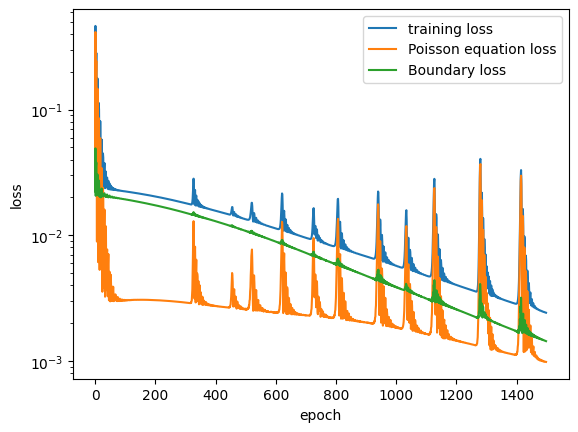

In [17]:
# Plot the losses
trainer_metrics = trainer.callbacks[0].metrics
loss = trainer_metrics["train_loss"].cpu()
loss_poisson = trainer_metrics["poisson_eq_loss"].cpu()
loss_bc = trainer_metrics["bound_cond1_loss"].cpu() + trainer_metrics["bound_cond2_loss"].cpu() + trainer_metrics["bound_cond3_loss"].cpu() + trainer_metrics["bound_cond4_loss"].cpu()
epochs = range(len(loss))
plt.plot(epochs, loss, label="training loss")
plt.plot(epochs, loss_poisson, label="Poisson equation loss")
plt.plot(epochs, loss_bc, label="Boundary loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.yscale("log")
plt.legend()


In [22]:
def solution(pts):
        """
        Implementation of the analytical solution of the Poisson problem.
        """
        sol = -(
            torch.sin(pts.extract(["x"]) * torch.pi)
            * torch.sin(pts.extract(["y"]) * torch.pi)
        )
        return sol

@torch.no_grad()
def plot_solution(solver):
    # get the problem
    problem = solver.problem
    # get spatial points
    spatial_samples = problem.spatial_domain.sample(30, "grid")
    # compute pinn solution, true solution and absolute difference
    data = {
        "PINN solution": solver(spatial_samples),
        "True solution": solution(spatial_samples),
        "Absolute Difference": torch.abs(
            solver(spatial_samples) - solution(spatial_samples)
        ),
    }
    # plot the solution
    for idx, (title, field) in enumerate(data.items()):
        plt.subplot(1, 3, idx + 1)
        plt.title(title)
        plt.tricontourf(  # convert to torch tensor + flatten
            spatial_samples.extract("x").tensor.flatten(),
            spatial_samples.extract("y").tensor.flatten(),
            field.tensor.flatten(),
        )
        plt.colorbar(), plt.tight_layout()

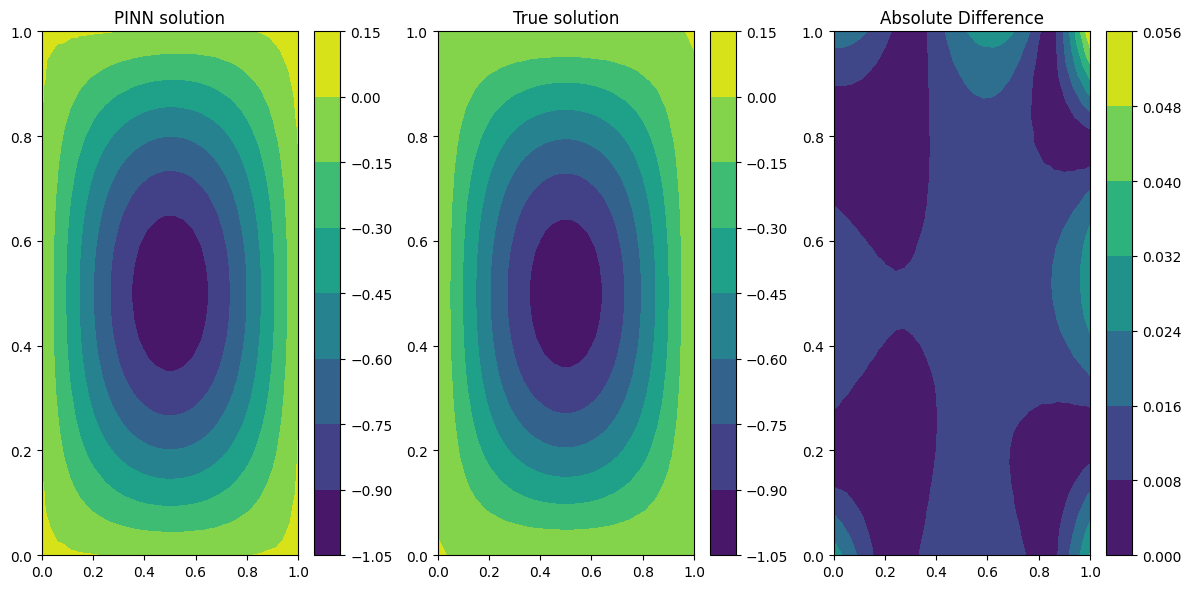

In [23]:
plt.figure(figsize=(12, 6))
plot_solution(solver=pinn)